<a href="https://colab.research.google.com/github/siva123h/NNDL/blob/main/Implement_Image_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Columns are:

Index(['Timestamp', 'age', 'Gender', 'Purchase_Frequency',
       'Purchase_Categories', 'Personalized_Recommendation_Frequency_1',
       'Browsing_Frequency', 'Product_Search_Method',
       'Search_Result_Exploration', 'Customer_Reviews_Importance',
       'Add_to_Cart_Browsing', 'Cart_Completion_Frequency',
       'Cart_Abandonment_Factors', 'Saveforlater_Frequency', 'Review_Left',
       'Review_Reliability', 'Review_Helpfulness',
       'Personalized_Recommendation_Frequency_2', 'Recommendation_Helpfulness',
       'Rating_Accuracy', 'Shopping_Satisfaction', 'Service_Appreciation',
       'Improvement_Areas'],
      dtype='object')

Dataset Shape: (602, 23)

Encoding Completed!


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,445 (52.52 KB)

 Trainable params: 13,445 (52.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2917 - loss: 1.5038 - val_accuracy: 0.3438 - val_loss: 1.3854
Epoch 2/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3698 - loss: 1.3666 - val_accuracy: 0.4271 - val_loss: 1.2921
Epoch 3/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4167 - loss: 1.3007 - val_accuracy: 0.4792 - val_loss: 1.2264
Epoch 4/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4714 - loss: 1.2437 - val_accuracy: 0.4896 - val_loss: 1.1665
Epoch 5/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5156 - loss: 1.1766 - val_accuracy: 0.4792 - val_loss: 1.1262
Epoch 6/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4922 - loss: 1.1463 - val_accuracy: 0.4583 - val_loss: 1.1106
Epoch 7/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4844 - loss: 1.1297 - val_accuracy: 0.4583 - val_loss: 1.0843
Epoch 8/40
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5208 - loss: 1.1558 - val_accuracy: 0.5000 - val_loss

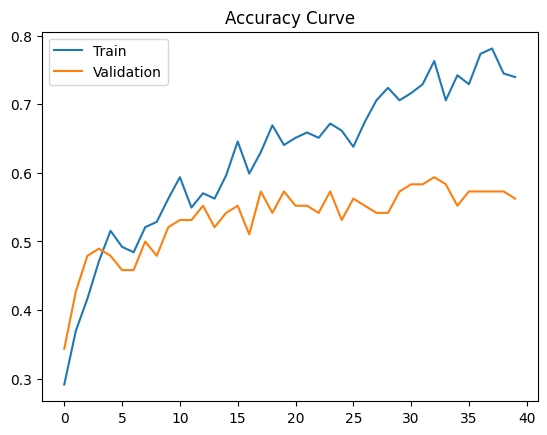

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Classification Report:

              precision    recall  f1-score   support

           0       0.56      0.43      0.49        21
           1       0.42      0.56      0.48        34
           2       0.62      0.63      0.62        46
           3       0.36      0.27      0.31        15
           4       1.00      0.25      0.40         4

    accuracy                           0.52       120
   macro avg       0.59      0.43      0.46       120
weighted avg       0.53      0.52      0.51       120



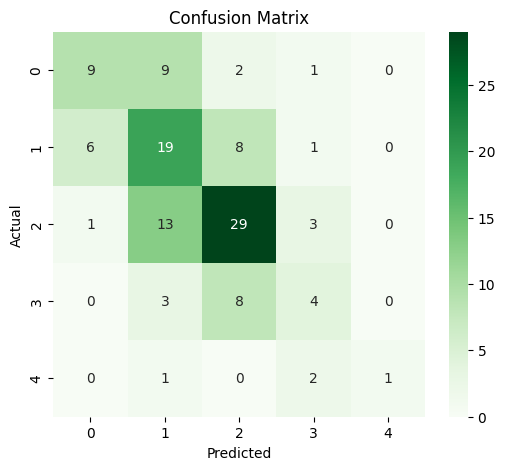


MODEL TRAINED & SAVED SUCCESSFULLY!


In [8]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# LOAD DATASET
df = pd.read_csv("/content/Amazon Customer Behavior Survey (1).csv")

# CLEAN COLUMN NAMES (VERY IMPORTANT)
df.columns = df.columns.str.strip()

# Handle duplicate column names if any
cols = pd.Series(df.columns)
for dup_col in cols[cols.duplicated()].unique():
    counter = 1
    for i in cols[cols == dup_col].index:
        cols[i] = f"{dup_col}_{counter}"
        counter += 1
df.columns = cols.tolist() # Convert back to list for DataFrame

print("Columns are:\n")
print(df.columns)
print("\nDataset Shape:", df.shape)

# REMOVE MISSING VALUES
df = df.dropna()

# ENCODE CATEGORICAL DATA
label_encoders = {}

for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

print("\nEncoding Completed!")

# SELECT TARGET COLUMN
TARGET = "Shopping_Satisfaction"   # <-- Make sure this exists exactly

X = df.drop(TARGET, axis=1)
y = df[TARGET]

# Adjust labels to be 0-indexed for sparse_categorical_crossentropy
y = y - 1

# SCALE FEATURES
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# BUILD NEURAL NETWORK
num_classes = len(np.unique(y))

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(32, activation='relu'),

    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# TRAIN
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=16,
    validation_split=0.2
)

# PLOT ACCURACY
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# EVALUATE
pred_probs = model.predict(X_test)
pred = np.argmax(pred_probs, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, pred))

# CONFUSION MATRIX
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SAVE MODEL
model.save("student_behaviour_model.h5")

print("\nMODEL TRAINED & SAVED SUCCESSFULLY!")